In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
CHD = pd.read_csv("CHD.csv")
CHD["Ticker"] = "CHD"

In [51]:
ETN = pd.read_csv("ETN.csv")
ETN["Ticker"] = "ETN"

In [52]:
LH = pd.read_csv("LH.csv")
LH["Ticker"] = "LH"

In [53]:
REGN = pd.read_csv("REGN.csv")
REGN["Ticker"] = "REGN"

In [54]:
SNPS = pd.read_csv("SNPS.csv")
SNPS["Ticker"] = "SNPS"

In [55]:
files = [CHD, ETN, LH, REGN, SNPS]

In [56]:
for fil in files:
    fil["Date"] = pd.to_datetime(fil["Date"])

In [57]:
df = pd.concat(files)

In [58]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2021-01-04,82.296,83.025,80.944,81.899,1355500,0.0,0.0,CHD
1,2021-01-05,81.805,82.240,80.641,81.162,1646300,0.0,0.0,CHD
2,2021-01-06,80.887,81.909,80.622,81.284,1439500,0.0,0.0,CHD
3,2021-01-07,80.547,81.152,79.554,80.291,1632300,0.0,0.0,CHD
4,2021-01-08,80.055,80.840,79.261,80.764,1722600,0.0,0.0,CHD
...,...,...,...,...,...,...,...,...,...
999,2024-12-23,493.920,507.950,488.660,492.580,1126900,0.0,0.0,SNPS
1000,2024-12-24,494.240,500.510,492.200,500.160,426500,0.0,0.0,SNPS
1001,2024-12-26,495.150,500.830,494.760,495.820,542100,0.0,0.0,SNPS
1002,2024-12-27,490.850,495.200,485.070,490.910,654800,0.0,0.0,SNPS


In [60]:
df['HL_diff'] = df['High'] - df['Low']
hl_zero_by_ticker = df.groupby('Ticker')['HL_diff'].agg(lambda s: (s == 0).any())
hl_zero_by_ticker # there is no such company

Ticker
CHD     False
ETN     False
LH      False
REGN    False
SNPS    False
Name: HL_diff, dtype: bool

In [96]:
max_price = df.groupby('Ticker')['High'].max().rename('Maximum Price')
min_price = df.groupby('Ticker')['Low'].min().rename('Minimum Price')
high_low = pd.concat([max_price, min_price], axis=1)
print("\n (High) and (Low):")
print(high_low)


 (High) and (Low):
        Maximum Price  Minimum Price
Ticker                              
CHD           112.471         67.703
ETN           376.194        105.061
LH            260.995        165.137
REGN         1206.030        439.118
SNPS          629.380        217.690


In [66]:
def second_extreme_idx(s, n=2, largest=True):
    s = s.dropna()
    if s.shape[0] < n:
        return np.nan
    if largest:
        idxs = s.nlargest(n).index
    else:
        idxs = s.nsmallest(n).index
    if len(idxs) < n:
        return np.nan
    return idxs[-1]

In [73]:
second_gain = {}
second_loss = {}
for ticker, g in df.groupby('Ticker'):
    s = g.set_index('Date')['log_ret']
    second_gain[ticker] = second_extreme_idx(s, n=2, largest=True)
    second_loss[ticker] = second_extreme_idx(s, n=2, largest=False)

second_gain_s = pd.Series(second_gain).rename('SecondHighest_Date')
second_loss_s = pd.Series(second_loss).rename('SecondHighest_Date')
second_extremes = pd.concat([second_gain_s, second_loss_s], axis=1)
print("log returns:")
print(second_extremes)

log returns:
     SecondHighest_Date SecondHighest_Date
CHD          2024-11-01         2022-05-18
ETN          2023-08-01         2024-07-24
LH           2022-10-25         2022-09-13
REGN         2023-03-23         2023-06-27
SNPS         2022-11-10         2024-09-03


In [98]:
second_gain = {}
second_loss = {}
for ticker, g in df.groupby('Ticker'):
    s = g.set_index('Date')['log_ret']
    second_gain[ticker] = second_extreme_idx(s, n=2, largest=True)
    second_loss[ticker] = second_extreme_idx(s, n=2, largest=False)

second_gain_s = pd.Series(second_gain).rename('Second_Highest_Date')
second_loss_s = pd.Series(second_loss).rename('Second_Highest_Date')
second_extremes = pd.concat([second_gain_s, second_loss_s], axis=1)
print("log returns - 2nd:")
print(second_extremes)

log returns - 2nd:
     Second_Highest_Date Second_Highest_Date
CHD           2024-11-01          2022-05-18
ETN           2023-08-01          2024-07-24
LH            2022-10-25          2022-09-13
REGN          2023-03-23          2023-06-27
SNPS          2022-11-10          2024-09-03


In [99]:
weekly_volume_median = {}
for ticker, g in df.groupby('Ticker'):
    gs = g.set_index('Date').sort_index()
    weekly = gs['Volume'].resample('W').sum()
    weekly_volume_median[ticker] = weekly.median()
weekly_volume_median = pd.Series(weekly_volume_median).rename('Median_Weekly_Vol')
print("Median calendar-week sum:")
print(weekly_volume_median)

Median calendar-week sum:
CHD     6693600.0
ETN     8995200.0
LH      3576040.0
REGN    2936600.0
SNPS    4203400.0
Name: Median_Weekly_Vol, dtype: float64


In [102]:
total_return = {}
for ticker, g in df.groupby('Ticker'):
    g = g.sort_values('Date')
    first = g['Close'].iloc[0]
    last = g['Close'].iloc[-1]
    total_return[ticker] = last/first - 1
total_return = pd.Series(total_return).rename('TotalReturn')
print(total_return.sort_values())
lowest_total = total_return.idxmin()
print(f"Firm with lowest ret: {lowest_total} (return = {total_return[lowest_total]:.5f})")

CHD     0.265840
LH      0.346112
REGN    0.455059
SNPS    0.911033
ETN     2.007064
Name: TotalReturn, dtype: float64
Firm with lowest ret: CHD (return = 0.26584)


In [103]:
df['volume_class'] = pd.qcut(df['Volume'], q=3, labels=['Low','Medium','High'])
print(df['volume_class'].value_counts())

volume_class
Low       1674
High      1674
Medium    1672
Name: count, dtype: int64


In [75]:
sp = pd.read_csv("companies_no_subindustry.csv")
sp

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981
...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",06.10.1997,1997
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",23.12.2019,1969
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",07.08.2001,1927
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",22.06.2001,1873


In [77]:
missing_included = sp['included'].isna().sum()
missing_included

np.int64(45)

In [79]:
sp2 = sp.copy()

sp2['included_dt'] = pd.to_datetime(sp2['included'], dayfirst=True, errors='coerce')
sp_clean = sp2.dropna(subset=['included_dt']).copy()

oldest = sp_clean.loc[sp_clean['included_dt'].idxmin()]
youngest = sp_clean.loc[sp_clean['included_dt'].idxmax()]

median_age_days = (sp_clean['included_dt'].max() - sp_clean['included_dt']).median()
median_age_years = median_age_days.days / 365.25

In [81]:
median_age_days, median_age_years, oldest, youngest

(Timedelta('5206 days 00:00:00'),
 14.25325119780972,
 Symbol                          MO
 Security                    Altria
 GICS_Sector       Consumer Staples
 hq              Richmond, Virginia
 included                04.03.1957
 Founded                       1985
 included_dt    1957-03-04 00:00:00
 Name: 25, dtype: object,
 Symbol                        ACGL
 Security        Arch Capital Group
 GICS_Sector             Financials
 hq               Hamilton, Bermuda
 included                01.11.2022
 Founded                       1995
 included_dt    2022-11-01 00:00:00
 Name: 48, dtype: object)


) Num of firms in sectors:
GICS_Sector
Information Technology    68
Industrials               66
Health Care               60
Financials                55
Consumer Discretionary    52
Consumer Staples          33
Real Estate               29
Materials                 26
Communication Services    22
Utilities                 22
Energy                    22
Name: count, dtype: int64


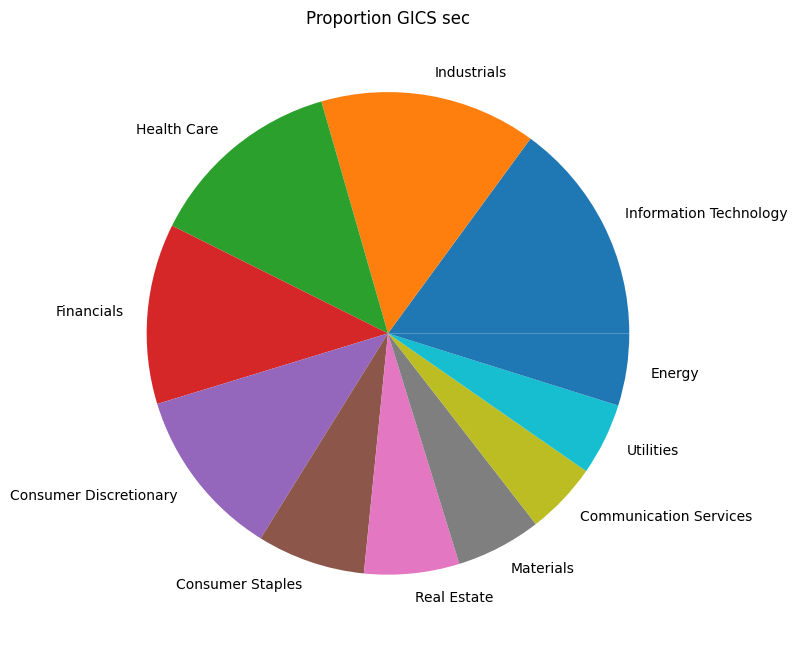

In [82]:
sector_counts = sp_clean['GICS_Sector'].value_counts()
print("\n) Num of firms in sectors:")
print(sector_counts)

plt.figure(figsize=(8,8))
plt.pie(sector_counts, labels=sector_counts.index)
plt.title("Proportion GICS sec")
plt.tight_layout()
plt.show()

Distribution (top 15):
state
California        65
New York          43
Texas             40
Illinois          31
Pennsylvania      19
Massachusetts     18
Ohio              17
North Carolina    16
Georgia           16
Florida           15
New Jersey        15
Virginia          15
Minnesota         13
Washington        12
Connecticut       12
Name: count, dtype: int64


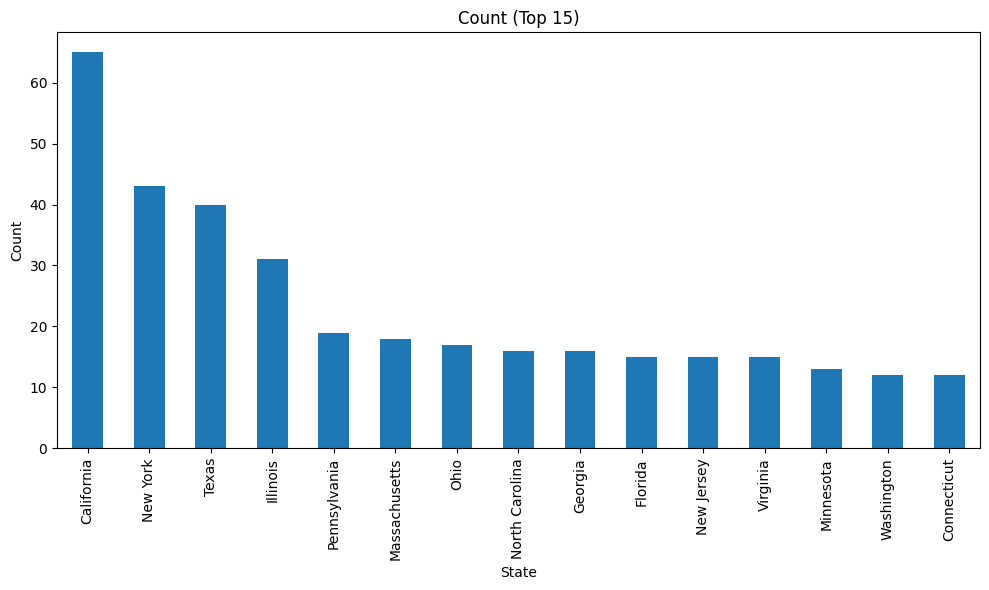

In [83]:
sp_clean['state'] = sp_clean['hq'].str.split(',').str[-1].str.strip()

state_counts = sp_clean['state'].value_counts()
print("Distribution (top 15):")
print(state_counts.head(15))

plt.figure(figsize=(10,6))
state_counts.head(15).plot(kind='bar')
plt.title("Count (Top 15)")
plt.xlabel("State")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [88]:
subind_df = pd.read_csv("companies_subindustry.csv")

Subindustry distr. in Health Care:
subindustry
Health Care Equipment             18
Pharmaceuticals                    9
Biotechnology                      7
Life Sciences Tools & Services     7
Managed Health Care                5
Health Care Supplies               4
Health Care Distributors           4
Health Care Services               3
Health Care Facilities             3
Name: count, dtype: int64


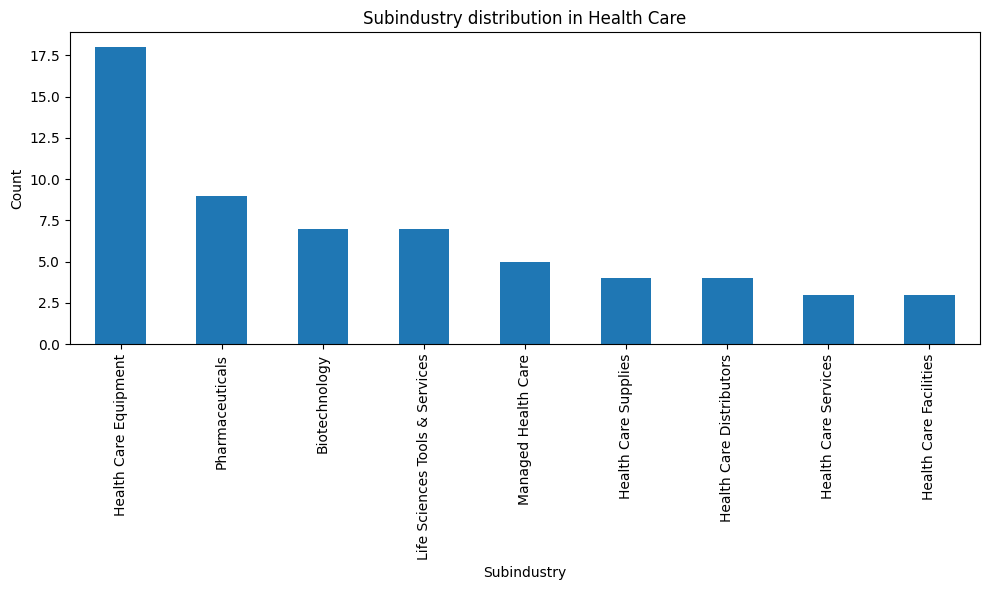

In [93]:
subind_df = pd.read_csv("companies_subindustry.csv")

merged = sp_clean.merge(subind_df, on="Symbol", how="left")

# Filter HC sector
health = merged[merged['GICS_Sector'] == "Health Care"]

# distrib sub-industry
sub_counts = health['subindustry'].value_counts()

print("Subindustry distr. in Health Care:")
print(sub_counts)

plt.figure(figsize=(10,6))
sub_counts.plot(kind='bar')
plt.title("Subindustry distribution in Health Care")
plt.xlabel("Subindustry")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [91]:
subind_df

,Symbol,subindustry
0,MMM,Industrial Conglomerates
1,AOS,Building Products
2,ABT,Health Care Equipment
3,ABBV,Pharmaceuticals
4,ABMD,Health Care Equipment
...,...,...
498,YUM,Restaurants
499,ZBRA,Electronic Equipment & Instruments
500,ZBH,Health Care Equipment
501,ZION,Regional Banks


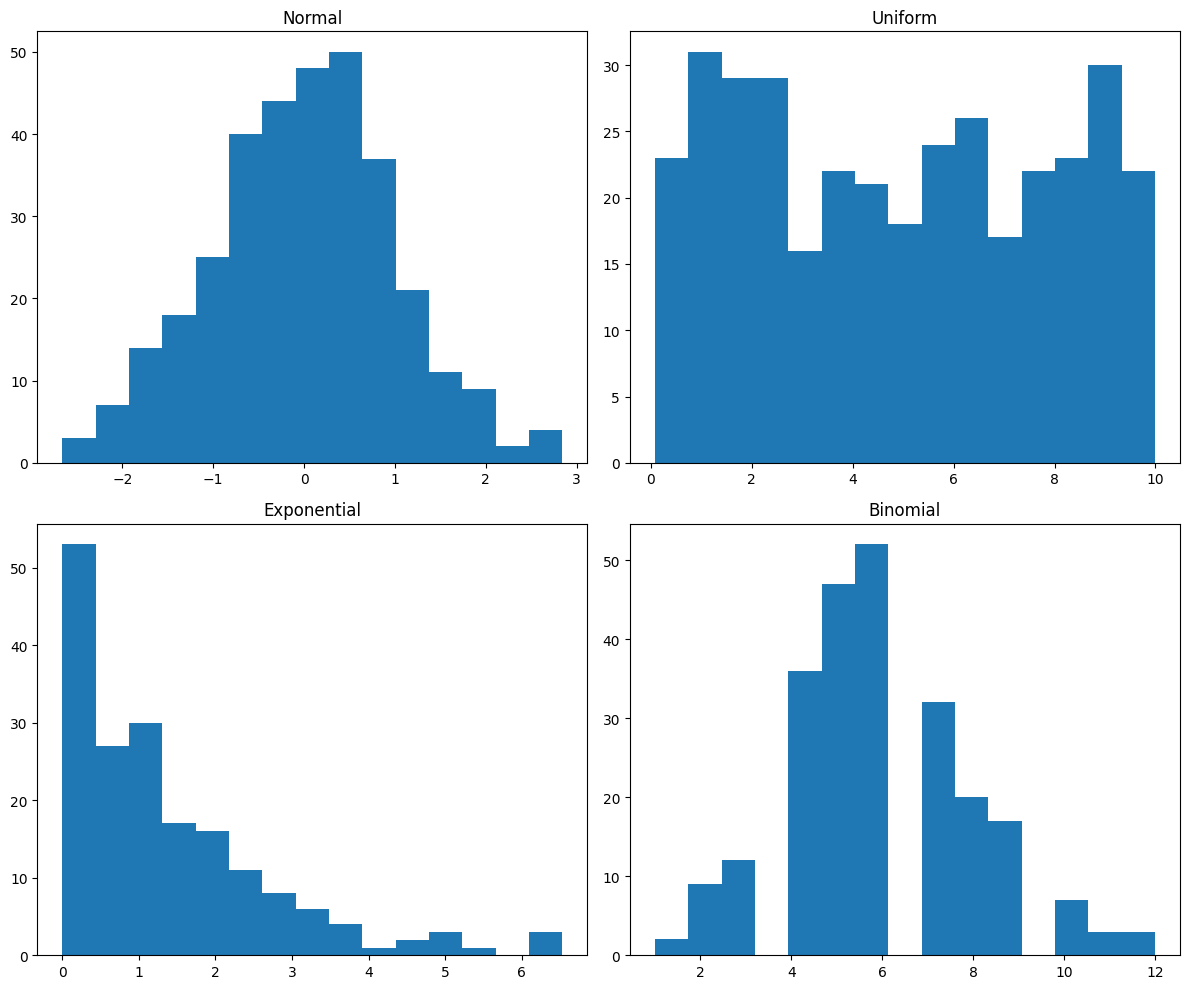

In [95]:
n1 = np.random.randint(100, 500)
n2 = np.random.randint(100, 500)
n3 = np.random.randint(100, 500)
n4 = np.random.randint(100, 500)

x1 = np.random.normal(loc=0, scale=1, size=n1)          # Normal 
x2 = np.random.uniform(low=0, high=10, size=n2)         # Uniform 
x3 = np.random.exponential(scale=1.5, size=n3)          # Exponental
x4 = np.random.binomial(n=20, p=0.3, size=n4)           # Binom

# Plot hist
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(x1, bins=15)
axes[0, 0].set_title("Normal")

axes[0, 1].hist(x2, bins=15)
axes[0, 1].set_title("Uniform")

axes[1, 0].hist(x3, bins=15)
axes[1, 0].set_title("Exponential")

axes[1, 1].hist(x4, bins=15)
axes[1, 1].set_title("Binomial")

plt.tight_layout()
plt.show()